# 02 - CT Physics Exploration

This notebook builds an understanding of the CT reconstruction problem by illustrating:

- What a sinogram is and how the Radon transform produces one
- Why sparse-view CT is an ill-posed inverse problem
- What artefacts appear when we reconstruct from too few angles
- How noise in the sinogram propagates into the image
- Why naive inversion (FBP) is not enough and how that motivates regularisation

The notebook runs entirely with numpy / scipy / skimage, so no tomosipo or LION is required as we are only aiming to visualise the problems, before using any of LION's operators. 

## 1. Setup

In [1]:
# import all necessary libraries
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage.transform import radon, iradon, resize
from skimage.data import shepp_logan_phantom
from skimage.util import img_as_float

# set a consistent figure style throughout the notebook
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "image.cmap": "gray",
    "image.interpolation": "nearest",
})

# Create figure output directory if it does not exist
output_dir = Path("../figures/02")
output_dir.mkdir(parents=True, exist_ok=True)

## 2. The Forward Model

In CT, the **forward model** is:

$$y = \mathcal{A}(x) + \varepsilon$$

where:
- $x \in \mathbb{R}^N$ is the unknown image we aim to recover
- $\mathcal{A}$ is the Radon transform
- $y \in \mathbb{R}^M$ is the sinogram
- $\varepsilon$ is measurement noise

The Radon transform at angle $\theta$ is a line integral along the direction perpendicular to angle $\theta$ at detector position $s$:

$$[\mathcal{A}x](\theta, s) = \int_{-\infty}^{\infty} x(s\cos\theta - t\sin\theta,\; s\sin\theta + t\cos\theta)\, dt$$

#### What is the reconstruction problem?

Given the measurements $y$, the reconstruction problem explores how we can obtain $x$.

## 3. The Shepp-Logan Phantom test image

Given it's similarity to clinical CT images, the Shepp-Logan Phantom is ideal for this exploration.

Phantom shape : (256, 256)
Value range   : [0.000, 1.000]


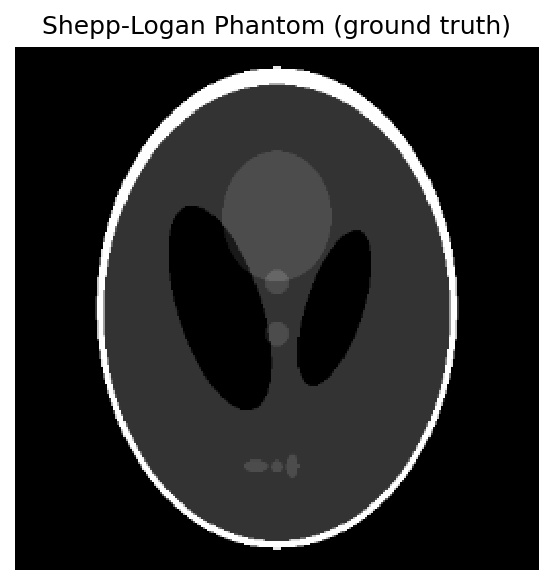

In [2]:
# Load phantom as a float
phantom = img_as_float(shepp_logan_phantom()) 

# resize to 256x256 to match paper
phantom = resize(phantom, (256, 256), anti_aliasing=True)

# print shape and value range of the phantom for verification
print(f"Phantom shape : {phantom.shape}")
print(f"Value range   : [{phantom.min():.3f}, {phantom.max():.3f}]")

# Visualise and save
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(phantom, cmap="gray", vmin=0, vmax=1)
ax.set_title("Shepp-Logan Phantom (ground truth)")
ax.axis("off")
plt.tight_layout()
plt.savefig("../figures/02/01_phantom.pdf", bbox_inches="tight")
plt.show()

## 4. The Sinogram

In full-view CT scans, projections are acquired over many viewing angles, where each row of the sinogram corresponds to a projection and each column corresponds to a detector pixel. The relationship between these projections and the reconstructed image is described by the Fourier Slice Theorem, which states that the one-dimensional Fourier transform of a projection is equivalent to a slice through the centre of the object's two-dimensional Fourier transform at the same angle. By collecting projections from many angles, the scanner samples Fourier space densely enough to provide sufficient information for accurate reconstructions of the original image.

In sparse-view CT, the number of projection angles is reduced to lower the X-ray dose or shorten the total scan time. As fewer projections are acquired, fewer slices of Fourier space are sampled, leaving gaps. The missing frequencies lead to streaking artefacts, loss of detail, and reduced image quality when conventional reconstruction methods are used. 

The TFPnP paper uses only 30 projection views, representing a 24× reduction compared to the standard 720-view full-sampling setup, making the reconstruction problem significantly more ill-posed and motivating the use of advanced iterative and learning-based reconstruction techniques.

In [3]:
# define projection angle counts for different doses
N_VIEWS_FULL = 720    # clinical standard
N_VIEWS_SPARSE = 30   # TFPnP paper setting (24x dose reduction)
N_VIEWS_MID = 60      # intermediate setting (12x dose reduction)

# define projection angles for each dose level
theta_full   = np.linspace(0, 180, N_VIEWS_FULL,   endpoint=False)
theta_sparse = np.linspace(0, 180, N_VIEWS_SPARSE, endpoint=False)
theta_mid    = np.linspace(0, 180, N_VIEWS_MID,    endpoint=False)

# forward project each dose level to compute sinograms
sino_full   = radon(phantom, theta=theta_full,   circle=True)
sino_mid    = radon(phantom, theta=theta_mid,    circle=True)
sino_sparse = radon(phantom, theta=theta_sparse, circle=True)

# print sinogram shapes and angle counts to confirm correct initialisation
print(f"Full sinogram shape   : {sino_full.shape}   ({N_VIEWS_FULL} angles)")
print(f"Mid sinogram shape    : {sino_mid.shape}    ({N_VIEWS_MID} angles)")
print(f"Sparse sinogram shape : {sino_sparse.shape}  ({N_VIEWS_SPARSE} angles)")

Full sinogram shape   : (256, 720)   (720 angles)
Mid sinogram shape    : (256, 60)    (60 angles)
Sparse sinogram shape : (256, 30)  (30 angles)


Visualising the sinograms will help illustrate the effect of sparse projections.

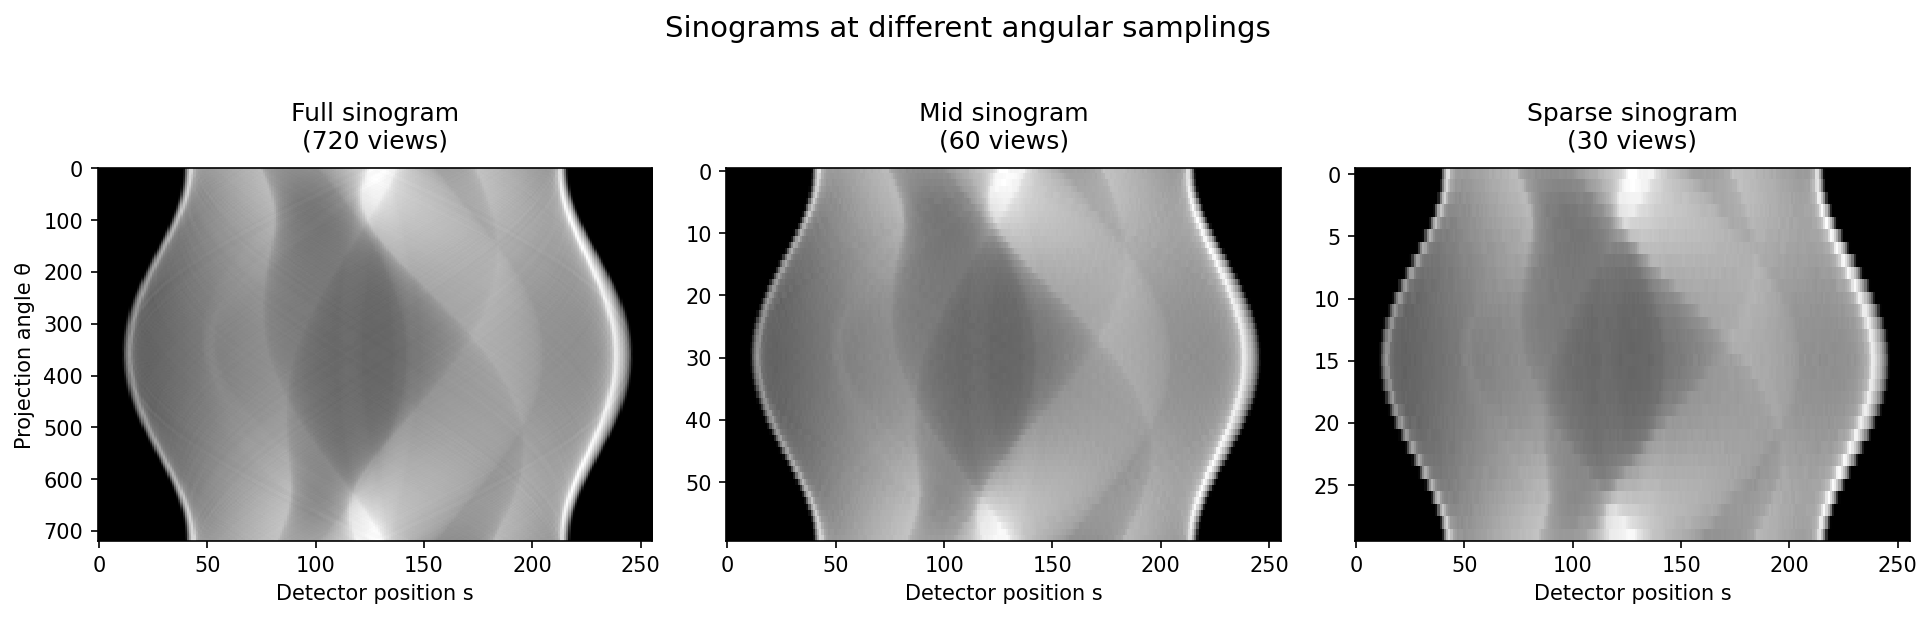

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(sino_full.T, aspect="auto", cmap="gray")
axes[0].set_title(f"Full sinogram\n({N_VIEWS_FULL} views)", y=1.02)
axes[0].set_xlabel("Detector position s")
axes[0].set_ylabel("Projection angle θ")

axes[1].imshow(sino_mid.T, aspect="auto", cmap="gray")
axes[1].set_title(f"Mid sinogram\n({N_VIEWS_MID} views)", y=1.02)
axes[1].set_xlabel("Detector position s")

axes[2].imshow(sino_sparse.T, aspect="auto", cmap="gray")
axes[2].set_title(f"Sparse sinogram\n({N_VIEWS_SPARSE} views)", y=1.02)
axes[2].set_xlabel("Detector position s")

plt.suptitle("Sinograms at different angular samplings", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("../figures/02/02_sinograms.pdf", bbox_inches="tight")
plt.show()

The rows of the sinogram correspond to the number of projections. We can see that in the full sinogram, there are enough projections to make the sinogram appear smooth across all egdes. As we move to the intermediate projection count, each individual row is more distinguishable than in the full sinogram, which results in a blocky and incoherent sinogram, an effect that is further amplified in the sparse sinogram, where the steps between each projection are very visible. 

## 5. Filtered Backprojection (FBP)

Filtered Backprojection (FBP) is the classical CT reconstruction algorithm that inverts the Radon transform analytically:

$$x_{\text{FBP}} = \mathcal{A}^\dagger y = \mathcal{R}^{-1} y$$

The filter works in Fourier space, and corrects for the inherent blurring in simple backprojection by amplifying high frequencies, which are where the finer details of each image are found. 

FBP is exact in the limit of infinitely many, noise-free projections, but breaks down with sparse or noisy measurements as it has no inherent mechanism for handling missing data or noise, and due to it amplifying all high frequencies equally, reconstructions are degraded as both noise and signal are amplified.

To mitigate this, a smoothing window can be added to the ramp filter (shepp-logan, cosine, hamming or ham), each of which apply different levels of smoothing and are best for different scenarios, with hamming and ham usually being too aggressive for CT reconstruction.

In [5]:
# Reconstruct with FBP at each dose level using standard ramp filter and `circle=True` to specify that the phantom is inscribed in a circle
recon_full   = iradon(sino_full,   theta=theta_full,   filter_name="ramp", circle=True)
recon_mid    = iradon(sino_mid,    theta=theta_mid,    filter_name="ramp", circle=True)
recon_sparse = iradon(sino_sparse, theta=theta_sparse, filter_name="ramp", circle=True)

# Clip to [0,1] to eliminate the negative values that FBP can produce
recon_full   = np.clip(recon_full,   0, 1)
recon_mid    = np.clip(recon_mid,    0, 1)
recon_sparse = np.clip(recon_sparse, 0, 1)

# compute PSNR for each reconstruction compared to the ground truth phantom
def psnr(gt, recon):

    """
    Peak Signal-to-Noise Ratio in dB.
    """

    # compute mean squared error (MSE) between ground truth and reconstruction
    mse = np.mean((gt - recon) ** 2)
    if mse == 0:
        return float("inf")
    
    # plug MSE into PSNR formula: PSNR = 10 * log10(MAX^2 / MSE)
    return 10 * np.log10(1.0 / mse)

# print PSNR values for each reconstruction
print(f"PSNR (720 views) : {psnr(phantom, recon_full):.2f} dB")
print(f"PSNR  (90 views) : {psnr(phantom, recon_mid):.2f} dB")
print(f"PSNR  (30 views) : {psnr(phantom, recon_sparse):.2f} dB")

PSNR (720 views) : 31.11 dB
PSNR  (90 views) : 28.17 dB
PSNR  (30 views) : 22.14 dB


There is a clear degradation of PSNR as we go from full to sparse view CT, but visualising the reconstructions will help build an understanding of why FBP fails at sparse projection counts, and what this degradation looks like.

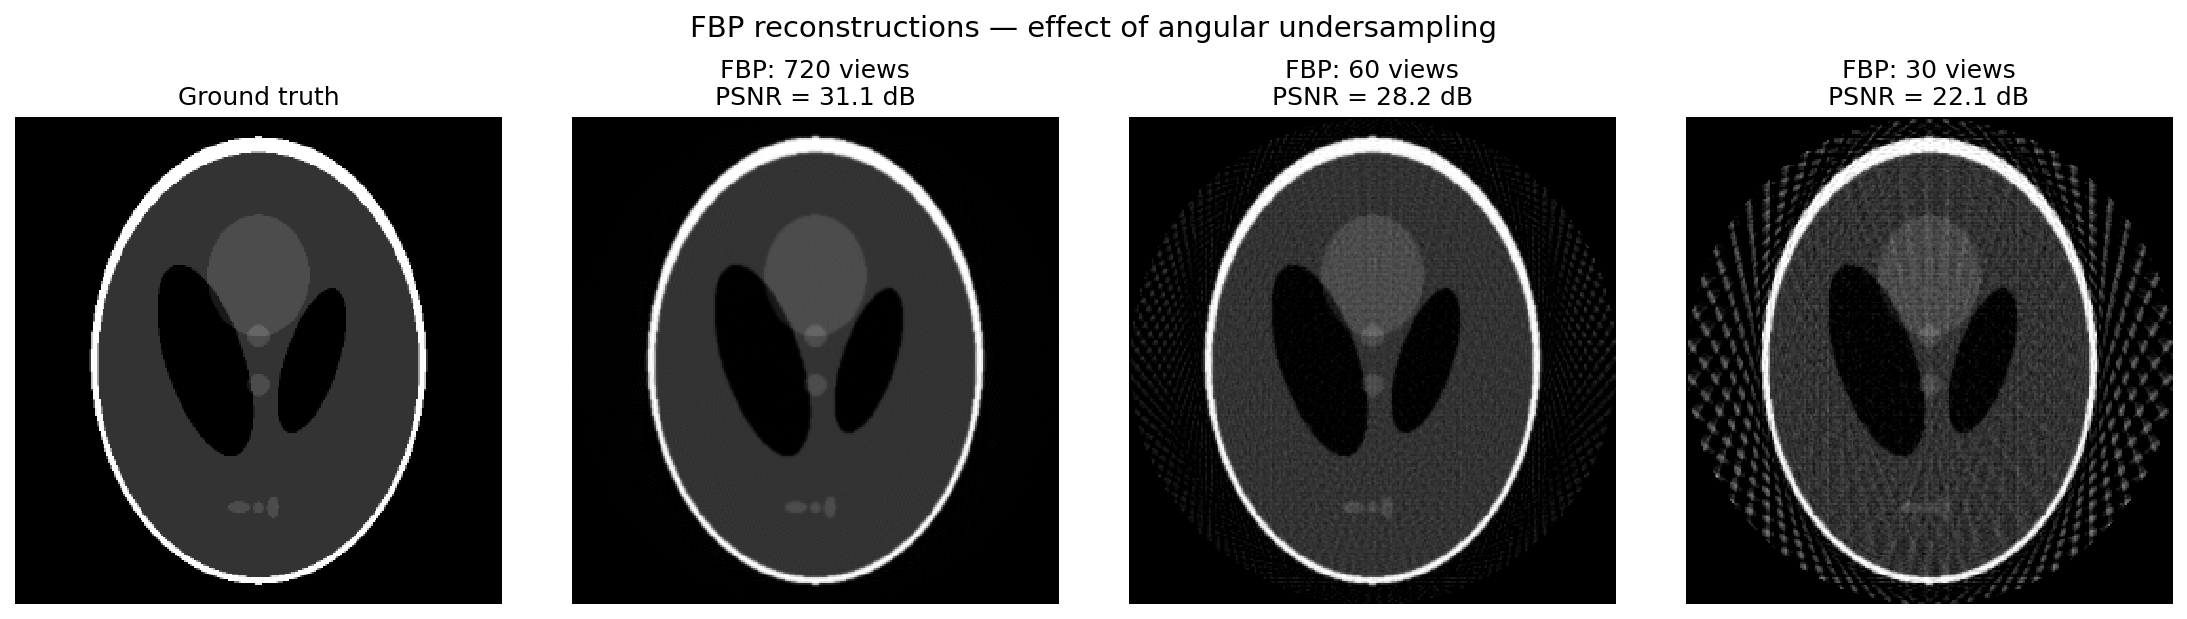

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# plot ground truth
axes[0].imshow(phantom, vmin=0, vmax=1)
axes[0].set_title("Ground truth")

# plot remaining reconstructions with their PSNR values
axes[1].imshow(recon_full, vmin=0, vmax=1)
axes[1].set_title(f"FBP: 720 views\nPSNR = {psnr(phantom, recon_full):.1f} dB")

axes[2].imshow(recon_mid, vmin=0, vmax=1)
axes[2].set_title(f"FBP: 60 views\nPSNR = {psnr(phantom, recon_mid):.1f} dB")

axes[3].imshow(recon_sparse,vmin=0, vmax=1)
axes[3].set_title(f"FBP: 30 views\nPSNR = {psnr(phantom, recon_sparse):.1f} dB")

# set axis off for cleaner look
for ax in axes:
    ax.axis("off")

# show and save final figure
plt.suptitle("FBP reconstructions — effect of angular undersampling", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("../figures/02/03_fbp_sparse_view.pdf", bbox_inches="tight")
plt.show()

The 720-view reconstruction is very close to the ground truth, with minimal artefacts or noise, and clear although slightly less sharper edges. The high PSNR score further confirms that it is a good reconstruction. 

The 60-view reconstruction has a PSNR 2.9dB lower than the full view reconstruction, which is still above the threshold for acceptable reconstructions, but there is visibly more noise throughout, and faint streak artefacts can be seen in the outer edges.

At 30-views, the streak artefacts are strong and dominate the image, with fine details beginning to become obscured due to severe angular undersampling. The PSNR here is reduced to 22.1dB, suggesting a progressively lower reconstruction accuracy.

## 6. Sparse-View Artefacts

The characteristic artefact seen in sparse-view CT are streak artefacts, which appear as radial streaks coming from high-contrast features such as bone edges. They arise due to FBP backprojecting each projection uniformly across the image, and with sparse views, these only overlap along the limited directions, creating directional shadows everywhere else. 

To illustrate this directional error, we compare the ground truth to the sparse reconstruction with an absolute error map.

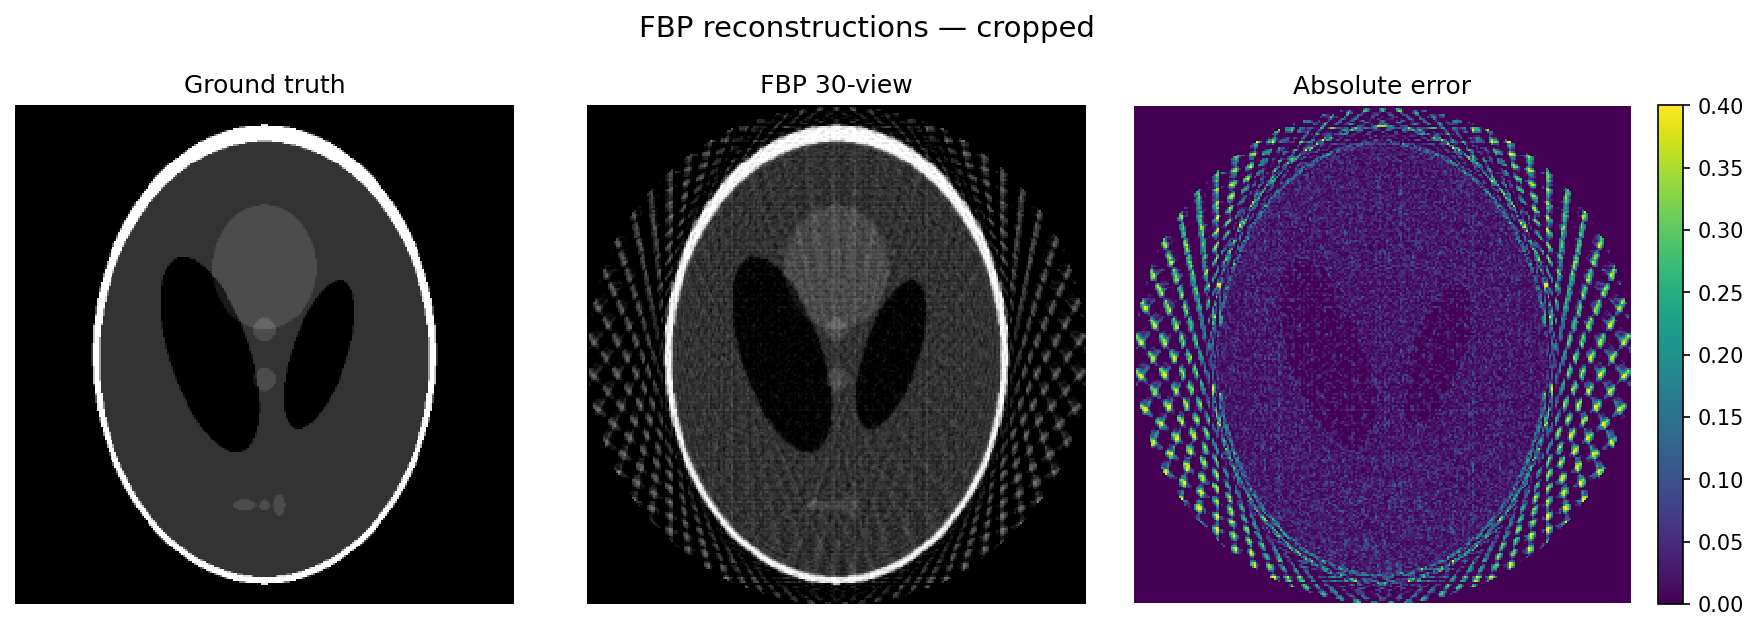

Max absolute error: 0.5755
Mean absolute error: 0.0390


In [7]:
# compute absolute error between ground truth and sparse reconstruction
diff = np.abs(phantom - recon_sparse)

# plot alongside eachother, with error heatmap to illustrate the differences
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(phantom, vmin=0, vmax=1)
axes[0].set_title("Ground truth")

axes[1].imshow(recon_sparse, vmin=0, vmax=1)
axes[1].set_title("FBP 30-view")

# add a heatmap to show the absolute error, set max to mean value for better contrast
im = axes[2].imshow(diff, cmap="viridis", vmin=0, vmax=0.4)
axes[2].set_title("Absolute error")
plt.colorbar(im, ax=axes[2], fraction=0.046)

# set axis off for cleaner look
for ax in axes:
    ax.axis("off")

# show and save final figure
plt.suptitle("FBP reconstructions — cropped", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("../figures/02/04_streak_artefacts.pdf", bbox_inches="tight")
plt.show()

# print max and mean absolute errors
print(f"Max absolute error: {diff.max():.4f}")
print(f"Mean absolute error: {diff.mean():.4f}")

The 30-view reconstruction recovers the overall structure of the phantom but exhibits prominent streak artefacts and increased noise due to the severe angular undersampling, which is characteristic of sparse-view CT reconstruction. The absolute error map shows that the largest errors are concentrated around object boundaries and along the streak artefacts, while most homogeneous regions are reconstructed more accurately. Although the maximum absolute error is 0.5755, the error map is displayed over the range 0–0.4 to improve visual contrast and highlight the spatial distribution of typical errors, as only a small number of pixels exceed this value while the mean absolute error is much lower at 0.0390.

## 7. Noise in the Sinogram

In the TFPnP paper, Gaussian noise is added to the sparse-view sinogram:

$$y = \mathcal{A}x + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I)$$

Three noise levels are tested: **5%, 7.5%, 10%** (as a fraction of the sinogram's standard deviation).

Reproducing this will help illustrate how noise degrades FBP, and why this is not an ideal reconstruction method for noisy measurements.

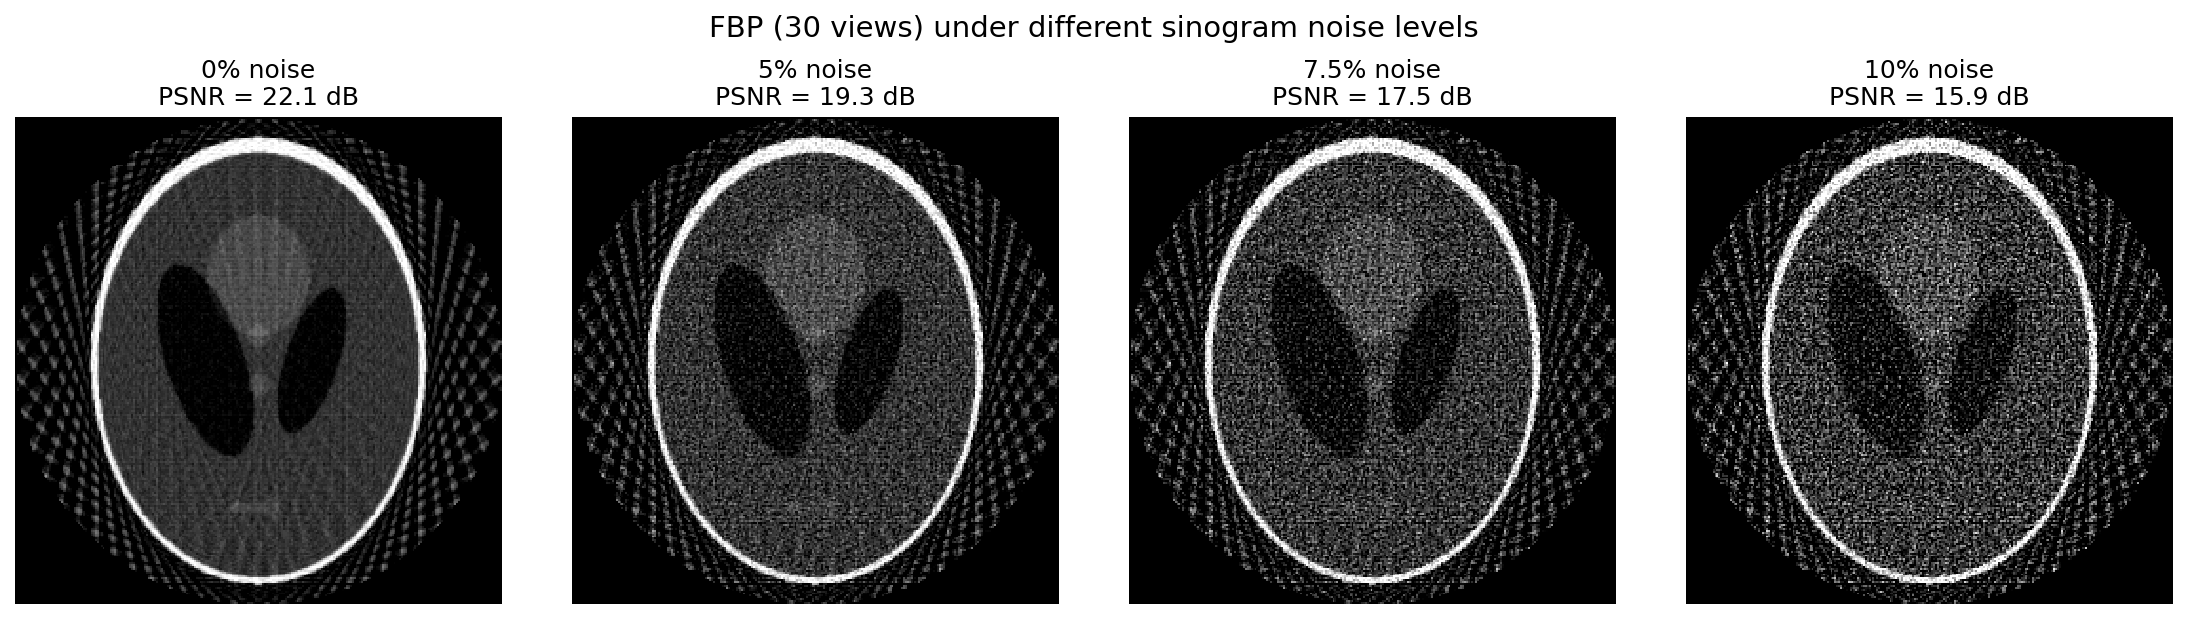

In [8]:
# Noise levels as fractions of sinogram std
noise_fracs = [0.0, 0.05, 0.075, 0.10]

# compute standard deviation of sparse sinogram to scale noise appropriately
sino_std = sino_sparse.std()

# create dictionary to store reconstructions at each noise level
recons_noisy = []

for frac in noise_fracs:

    # using random seed, set noise to be gaussian and of the same shape as sinogram
    noise = np.random.default_rng(42).normal(0, frac * sino_std, sino_sparse.shape)

    # add noise to sparse sinogram
    sino_noisy = sino_sparse + noise

    # reconstruct with FBP as before
    recon = iradon(sino_noisy, theta=theta_sparse, filter_name="ramp", circle=True)

    # clip to eliminate negative values
    recon = np.clip(recon, 0, 1)

    # append to dictionary
    recons_noisy.append(recon)

# plot different noise levels and PSNR values
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
titles = ["0% noise", "5% noise", "7.5% noise", "10% noise"]

for ax, recon, title, frac in zip(axes, recons_noisy, titles, noise_fracs):
    ax.imshow(recon, vmin=0, vmax=1)
    ax.set_title(f"{title}\nPSNR = {psnr(phantom, recon):.1f} dB")
    ax.axis("off")

# show and save final figure
plt.suptitle("FBP (30 views) under different sinogram noise levels", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("../figures/02/05_noise_effects.pdf", bbox_inches="tight")
plt.show()

The figure shows the combined effect of angular undersampling and increasing sinogram noise on FBP reconstruction quality. As the noise level increases from 0% to 10%, the reconstructions become progressively grainier and structural details become less distinct, while the streak artefacts caused by sparse angular sampling remain visible throughout. This degradation is reflected in the PSNR, which decreases from 22.1 dB at 0% noise to 15.9 dB at 10% noise, indicating a substantial loss of reconstruction quality. The results demonstrate that FBP is sensitive to both sparse-view sampling and measurement noise, with noise amplification further reducing image fidelity as the sinogram becomes more corrupted.

## 8. Why This is an Ill-Posed Inverse Problem

The reconstruction problem we are computing is:

$$\min_{x} \frac{1}{2} \| \mathcal{A}x - y \|^2$$

With 30 views, 182 detector bins and a 256×256 image, we have:
- Unknowns: $256 \times 256 = 65{,}536$ pixels
- Measurements: $30 \times 182 = 5{,}460$ sinogram values

For an ideal reconstruction, we aim to have the same or more measurements than unknows, but in this case our system is massively underdetermined, with many images $x$ being consistent with the same measurement $y$, creating an ill-posed problem.

*A problem is ill-posed if it fails any of the following conditions:*
*- It has a solution that exists*
*- It has a solution that is unique*
*- It has a solution that changes continuously with data*

To get a unique, meaningful solution we need to add regularisation, which is a mathematical technique for encoding prior knowledge into the reconstruction problem about what CT images should look like, by adding a penalty term $R(x)$ into the optimisation problem.

$$\min_{x} \underbrace{\frac{1}{2}\|\mathcal{A}x - y\|^2}_{\text{data fidelity}} + \lambda \underbrace{R(x)}_{\text{regulariser}}$$

## 9. Summary and Key Findings

This section investigated the challenges of sparse-view CT reconstruction using filtered backprojection (FBP) on simulated 30-view CT data. Reconstruction quality was evaluated under both noiseless and noisy acquisition conditions, demonstrating the effects of severe angular undersampling and increasing levels of measurement noise. Visual inspection and quantitative metrics showed that while FBP is capable of recovering the overall anatomy, image quality is significantly degraded by streak artefacts and noise amplification. These experiments establish a baseline against which more advanced iterative and learning-based reconstruction methods can be compared.

The 30-view FBP reconstruction exhibited substantial streak artefacts due to the limited number of projection angles, highlighting the ill-posed nature of sparse-view CT reconstruction. The mean absolute reconstruction error remained relatively low, indicating that the global image structure was recovered successfully, although large localised errors occurred near object boundaries and artefacts. Increasing sinogram noise from 0% to 10% produced progressively noisier reconstructions and reduced the PSNR from 22.1 dB to 15.9 dB, demonstrating the sensitivity of FBP to measurement noise. Overall, the results show that conventional FBP struggles under sparse and noisy acquisition conditions, motivating the use of regularised iterative methods and modern machine learning approaches for low-dose CT reconstruction.